# AI Gatekeeper Evaluation: Random Forest Classifier

Notebook ini fokus pada **evaluasi performa AI Gatekeeper** untuk regime classification.

## 🎯 Tujuan:
- Melatih dan mengevaluasi **Random Forest Classifier**
- Menganalisis **performa klasifikasi** (Accuracy, Precision, Recall, F1)
- Membandingkan **Actual vs Predicted** regime
- Mengidentifikasi **feature importance**
- Optimasi hyperparameter untuk model terbaik

## 📊 Classification Task:
- **Binary Classification**: Bearish (0) vs Bullish (1)
- **Features**: Vol_20, Mom_20, Mom_50 (market-wide indicators)
- **Target**: Next-day market regime

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

# Config
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


## 1. Data Loading & Preprocessing

In [2]:
# Load Data
file_path = 'dataset_2023_2025.xlsx'
data = pd.read_excel(file_path, index_col=0, parse_dates=True)
print(f"📊 Loaded {len(data)} rows of data")
print(f"📅 Date range: {data.index[0]} to {data.index[-1]}")
print(f"💰 Assets: {list(data.columns)}")

📊 Loaded 990 rows of data
📅 Date range: 2023-04-17 00:00:00 to 2025-12-31 00:00:00
💰 Assets: ['AAVE-USD', 'ADA-USD', 'BCH-USD', 'BNB-USD', 'BTC-USD', 'CRO-USD', 'DAI-USD', 'DASH-USD', 'DOGE-USD', 'ETH-USD', 'KCS-USD', 'LINK-USD', 'LTC-USD', 'MKR-USD', 'OKB-USD', 'PEPE24478-USD', 'SHIB-USD', 'SOL-USD', 'UNI7083-USD', 'USDC-USD', 'USDT-USD', 'XMR-USD', 'XRP-USD', 'ZEC-USD']


## 2. Feature Engineering & Labeling

In [3]:
# Calculate returns
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

# Create features
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

# Binary labeling: 0 = Bearish, 1 = Bullish
features['Target'] = (market_return.shift(-1) > 0).astype(int)
features = features.dropna()

print("\n=== Feature Statistics ===")
print(features.describe())

print("\n=== Target Distribution ===")
target_dist = features['Target'].value_counts()
print(f"Bearish (0): {target_dist[0]} days ({target_dist[0]/len(features)*100:.1f}%)")
print(f"Bullish (1): {target_dist[1]} days ({target_dist[1]/len(features)*100:.1f}%)")


=== Feature Statistics ===
           Vol_20      Mom_20      Mom_50      Target
count  927.000000  927.000000  927.000000  927.000000
mean     0.026746    0.001915    0.001912    0.548004
std      0.008193    0.006304    0.004056    0.497959
min      0.010481   -0.014521   -0.006813    0.000000
25%      0.020885   -0.002194   -0.001175    0.000000
50%      0.026325    0.001098    0.001255    1.000000
75%      0.031759    0.005080    0.004360    1.000000
max      0.049392    0.025813    0.013732    1.000000

=== Target Distribution ===
Bearish (0): 419 days (45.2%)
Bullish (1): 508 days (54.8%)


## 3. Train/Test Split

In [4]:
# Split by year
train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train = features.loc[train_mask, ['Vol_20', 'Mom_20', 'Mom_50']]
y_train = features.loc[train_mask, 'Target']
X_test = features.loc[test_mask, ['Vol_20', 'Mom_20', 'Mom_50']]
y_test = features.loc[test_mask, 'Target']

print("=== Data Split ===")
print(f"Training set: {len(X_train)} samples ({X_train.index[0]} to {X_train.index[-1]})")
print(f"Testing set: {len(X_test)} samples ({X_test.index[0]} to {X_test.index[-1]})")
print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\nTesting target distribution:")
print(y_test.value_counts())

=== Data Split ===
Training set: 562 samples (2023-06-19 00:00:00 to 2024-12-31 00:00:00)
Testing set: 365 samples (2025-01-01 00:00:00 to 2025-12-31 00:00:00)

Training target distribution:
Target
1    312
0    250
Name: count, dtype: int64

Testing target distribution:
Target
1    196
0    169
Name: count, dtype: int64


## 4. Baseline Model Training

In [5]:
# Train baseline Random Forest
print("🔄 Training baseline Random Forest Classifier...")

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    min_samples_split=10,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train)

# Predictions
y_train_pred = rf_baseline.predict(X_train)
y_test_pred = rf_baseline.predict(X_test)
y_test_proba = rf_baseline.predict_proba(X_test)[:, 1]

print("✅ Model trained successfully!")

🔄 Training baseline Random Forest Classifier...
✅ Model trained successfully!


## 5. Performance Metrics

In [6]:
# Calculate metrics
def calculate_metrics(y_true, y_pred, dataset_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"\n{'='*50}")
    print(f"{dataset_name} Performance")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-Score': f1}

# Training metrics
train_metrics = calculate_metrics(y_train, y_train_pred, "TRAINING SET")

# Testing metrics
test_metrics = calculate_metrics(y_test, y_test_pred, "TESTING SET")

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_test_proba)
print(f"\nROC-AUC Score: {roc_auc:.4f}")


TRAINING SET Performance
Accuracy:  0.9359 (93.59%)
Precision: 0.9233
Recall:    0.9647
F1-Score:  0.9436

TESTING SET Performance
Accuracy:  0.5205 (52.05%)
Precision: 0.5393
Recall:    0.7347
F1-Score:  0.6220

ROC-AUC Score: 0.4958


In [7]:
# Detailed classification report
print("\n=== Detailed Classification Report (Test Set) ===")
print(classification_report(y_test, y_test_pred, target_names=['Bearish', 'Bullish']))


=== Detailed Classification Report (Test Set) ===
              precision    recall  f1-score   support

     Bearish       0.47      0.27      0.34       169
     Bullish       0.54      0.73      0.62       196

    accuracy                           0.52       365
   macro avg       0.50      0.50      0.48       365
weighted avg       0.51      0.52      0.49       365



## 6. Confusion Matrix Visualization

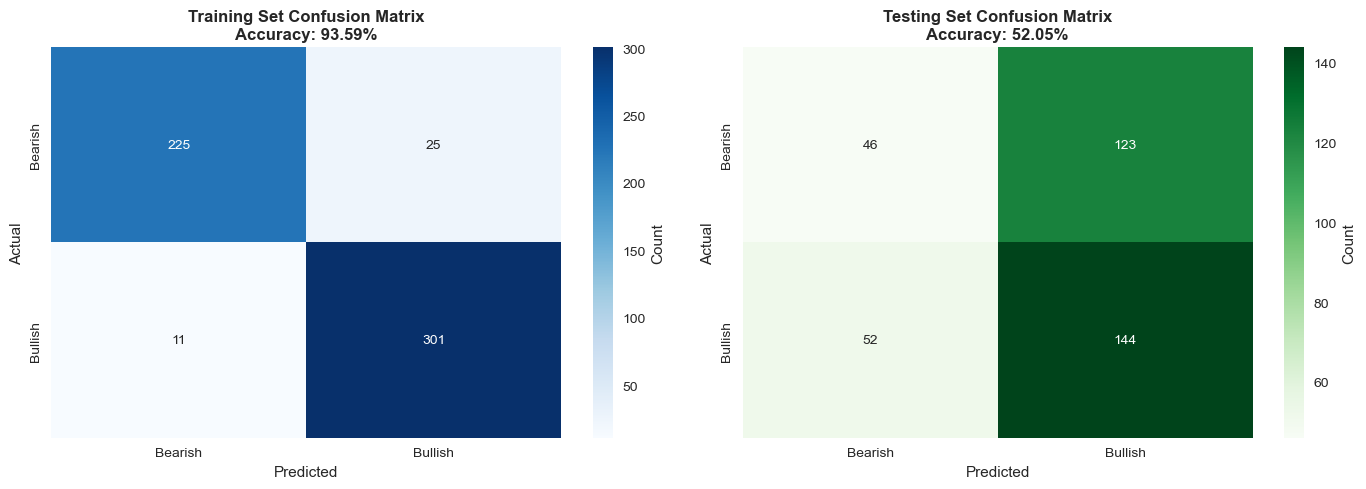

In [8]:
# Confusion matrices
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training confusion matrix
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Bearish', 'Bullish'],
            yticklabels=['Bearish', 'Bullish'],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title(f'Training Set Confusion Matrix\nAccuracy: {train_metrics["Accuracy"]:.2%}', 
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_xlabel('Predicted', fontsize=11)

# Testing confusion matrix
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Bearish', 'Bullish'],
            yticklabels=['Bearish', 'Bullish'],
            ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title(f'Testing Set Confusion Matrix\nAccuracy: {test_metrics["Accuracy"]:.2%}', 
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=11)
axes[1].set_xlabel('Predicted', fontsize=11)

plt.tight_layout()
plt.show()

## 7. Actual vs Predicted Visualization

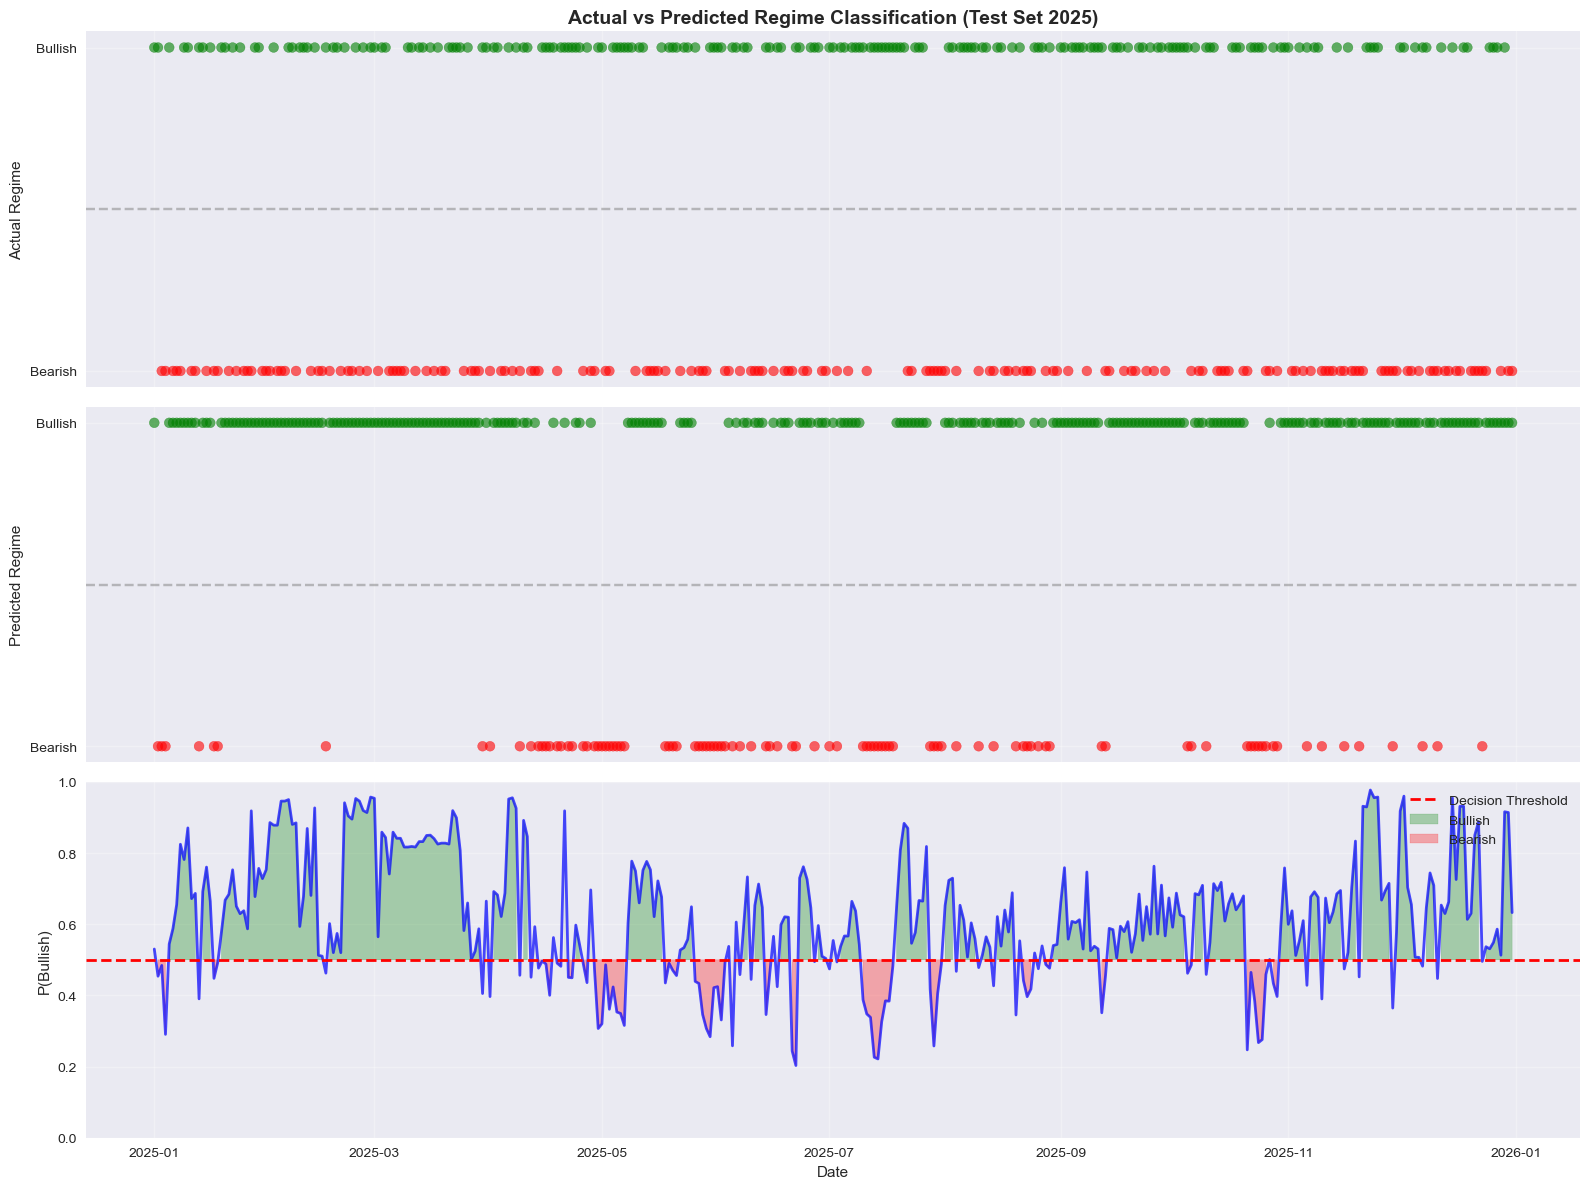


✅ Prediction Match: 52.05% (190/365 days)


In [9]:
# Create comparison dataframe
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred,
    'Probability': y_test_proba
}, index=y_test.index)

# Plot actual vs predicted
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# 1. Actual regime
colors_actual = ['red' if x == 0 else 'green' for x in comparison['Actual']]
axes[0].scatter(comparison.index, comparison['Actual'], c=colors_actual, alpha=0.6, s=50)
axes[0].set_ylabel('Actual Regime', fontsize=11)
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['Bearish', 'Bullish'])
axes[0].set_title('Actual vs Predicted Regime Classification (Test Set 2025)', 
                  fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# 2. Predicted regime
colors_pred = ['red' if x == 0 else 'green' for x in comparison['Predicted']]
axes[1].scatter(comparison.index, comparison['Predicted'], c=colors_pred, alpha=0.6, s=50)
axes[1].set_ylabel('Predicted Regime', fontsize=11)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Bearish', 'Bullish'])
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# 3. Prediction probability
axes[2].plot(comparison.index, comparison['Probability'], linewidth=2, color='blue', alpha=0.7)
axes[2].axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Decision Threshold')
axes[2].fill_between(comparison.index, 0.5, comparison['Probability'], 
                     where=(comparison['Probability'] >= 0.5), alpha=0.3, color='green', label='Bullish')
axes[2].fill_between(comparison.index, comparison['Probability'], 0.5, 
                     where=(comparison['Probability'] < 0.5), alpha=0.3, color='red', label='Bearish')
axes[2].set_ylabel('P(Bullish)', fontsize=11)
axes[2].set_xlabel('Date', fontsize=11)
axes[2].set_ylim([0, 1])
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate match percentage
match_pct = (comparison['Actual'] == comparison['Predicted']).sum() / len(comparison) * 100
print(f"\n✅ Prediction Match: {match_pct:.2f}% ({(comparison['Actual'] == comparison['Predicted']).sum()}/{len(comparison)} days)")

## 8. ROC Curve Analysis

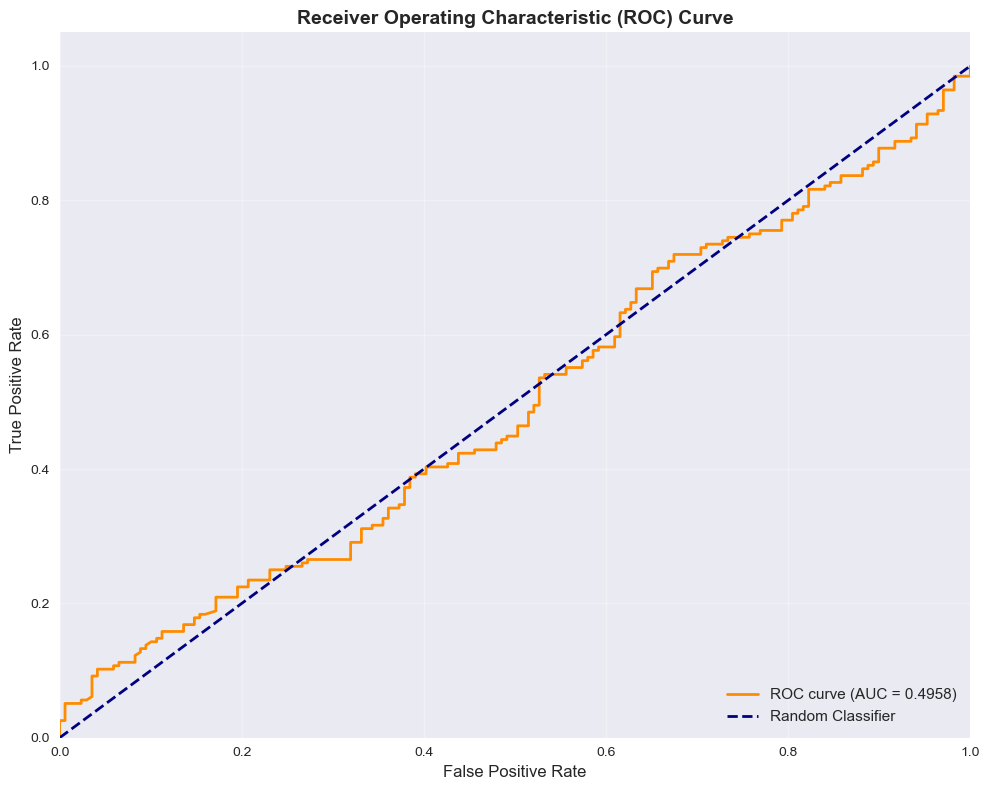

In [10]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Feature Importance Analysis


=== Feature Importance ===
  Feature  Importance
2  Mom_50    0.349341
1  Mom_20    0.334772
0  Vol_20    0.315886


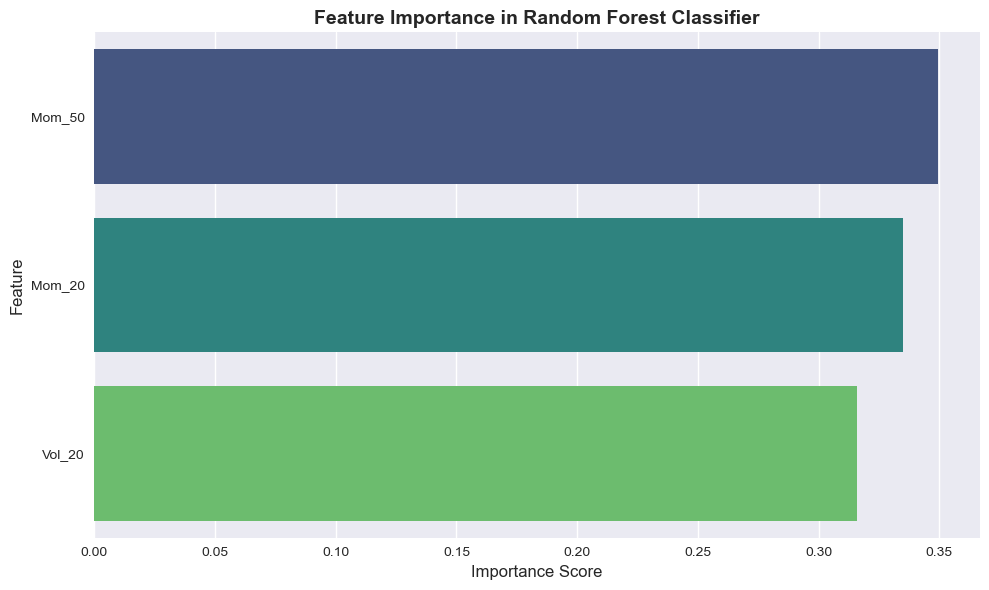

In [11]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_baseline.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n=== Feature Importance ===")
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance in Random Forest Classifier', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Cross-Validation Analysis

🔄 Performing 5-Fold Cross-Validation...

=== Cross-Validation Results ===
CV Scores: [0.51327434 0.47787611 0.38392857 0.52678571 0.51785714]
Mean CV Score: 0.4839 (+/- 0.1054)


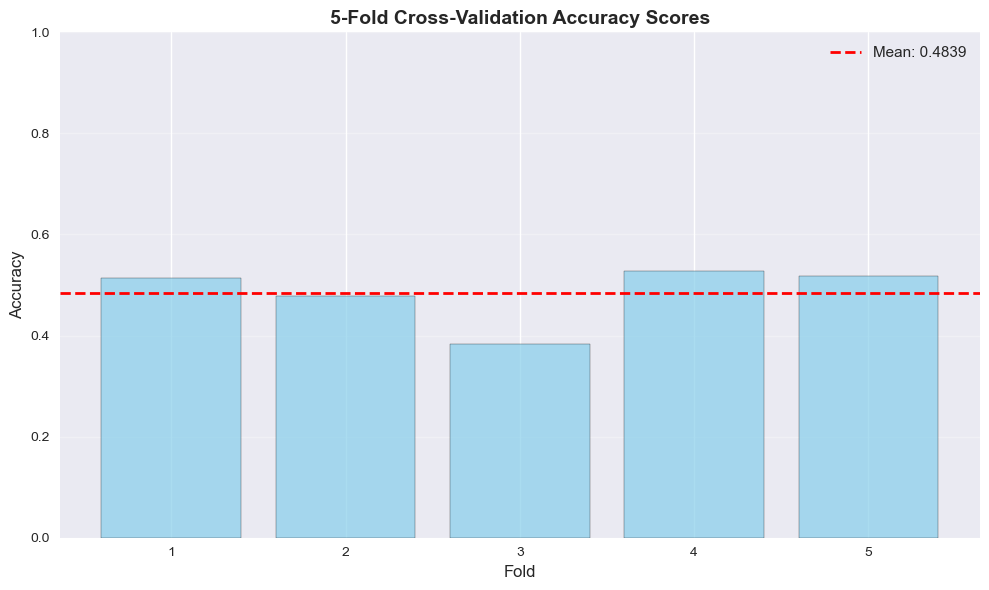

In [12]:
# Cross-validation on training set
print("🔄 Performing 5-Fold Cross-Validation...")

cv_scores = cross_val_score(rf_baseline, X_train, y_train, cv=5, scoring='accuracy')

print("\n=== Cross-Validation Results ===")
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Visualize CV scores
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), cv_scores, alpha=0.7, color='skyblue', edgecolor='black')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('5-Fold Cross-Validation Accuracy Scores', fontsize=14, fontweight='bold')
plt.ylim([0, 1])
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 11. Hyperparameter Tuning (Optional)

In [13]:
# Grid search for optimal hyperparameters
print("🔍 Searching for optimal hyperparameters...")

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\n=== Best Hyperparameters ===")
print(grid_search.best_params_)
print(f"\nBest CV Score: {grid_search.best_score_:.4f}")

# Evaluate best model
best_model = grid_search.best_estimator_
y_test_pred_best = best_model.predict(X_test)
best_accuracy = accuracy_score(y_test, y_test_pred_best)

print(f"\nTest Set Accuracy (Best Model): {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"Improvement over baseline: {(best_accuracy - test_metrics['Accuracy'])*100:.2f}%")

🔍 Searching for optimal hyperparameters...
Fitting 3 folds for each of 108 candidates, totalling 324 fits

=== Best Hyperparameters ===
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}

Best CV Score: 0.5605

Test Set Accuracy (Best Model): 0.5068 (50.68%)
Improvement over baseline: -1.37%


## 12. Error Analysis


=== Error Analysis ===
Error_Type
Correct           190
False Positive    123
False Negative     52
Name: count, dtype: int64


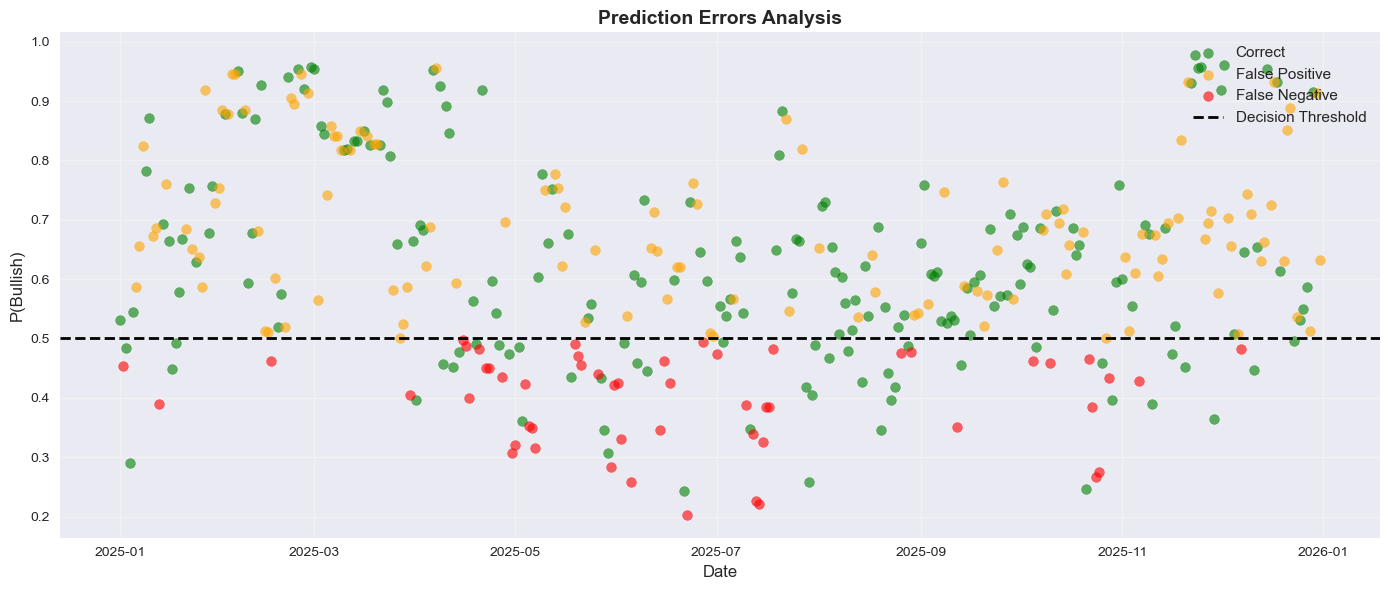


=== Misclassification Statistics ===

False Positives (Predicted Bullish, Actually Bearish): 123
  Average Probability: 0.6902
  Probability Range: 0.5011 - 0.9554

False Negatives (Predicted Bearish, Actually Bullish): 52
  Average Probability: 0.3976
  Probability Range: 0.2030 - 0.4967


In [14]:
# Analyze misclassifications
comparison['Correct'] = comparison['Actual'] == comparison['Predicted']
comparison['Error_Type'] = 'Correct'
comparison.loc[(comparison['Actual'] == 0) & (comparison['Predicted'] == 1), 'Error_Type'] = 'False Positive'
comparison.loc[(comparison['Actual'] == 1) & (comparison['Predicted'] == 0), 'Error_Type'] = 'False Negative'

print("\n=== Error Analysis ===")
print(comparison['Error_Type'].value_counts())

# Visualize errors
fig, ax = plt.subplots(figsize=(14, 6))

# Plot with different colors for error types
for error_type, color in [('Correct', 'green'), ('False Positive', 'orange'), ('False Negative', 'red')]:
    mask = comparison['Error_Type'] == error_type
    ax.scatter(comparison[mask].index, comparison[mask]['Probability'], 
               c=color, label=error_type, alpha=0.6, s=50)

ax.axhline(y=0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('P(Bullish)', fontsize=12)
ax.set_title('Prediction Errors Analysis', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Statistics of misclassifications
print("\n=== Misclassification Statistics ===")
false_positives = comparison[comparison['Error_Type'] == 'False Positive']
false_negatives = comparison[comparison['Error_Type'] == 'False Negative']

print(f"\nFalse Positives (Predicted Bullish, Actually Bearish): {len(false_positives)}")
if len(false_positives) > 0:
    print(f"  Average Probability: {false_positives['Probability'].mean():.4f}")
    print(f"  Probability Range: {false_positives['Probability'].min():.4f} - {false_positives['Probability'].max():.4f}")

print(f"\nFalse Negatives (Predicted Bearish, Actually Bullish): {len(false_negatives)}")
if len(false_negatives) > 0:
    print(f"  Average Probability: {false_negatives['Probability'].mean():.4f}")
    print(f"  Probability Range: {false_negatives['Probability'].min():.4f} - {false_negatives['Probability'].max():.4f}")

## 13. Summary & Recommendations

In [15]:
print("\n" + "="*70)
print("AI GATEKEEPER EVALUATION SUMMARY")
print("="*70)

print("\n📊 MODEL CONFIGURATION:")
print(f"  Algorithm: Random Forest Classifier")
print(f"  Features: {list(X_train.columns)}")
print(f"  Training Period: {X_train.index[0].date()} to {X_train.index[-1].date()}")
print(f"  Testing Period: {X_test.index[0].date()} to {X_test.index[-1].date()}")

print("\n📈 PERFORMANCE METRICS (Test Set):")
print(f"  Accuracy:  {test_metrics['Accuracy']:.4f} ({test_metrics['Accuracy']*100:.2f}%)")
print(f"  Precision: {test_metrics['Precision']:.4f}")
print(f"  Recall:    {test_metrics['Recall']:.4f}")
print(f"  F1-Score:  {test_metrics['F1-Score']:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

print("\n🎯 CROSS-VALIDATION:")
print(f"  Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

print("\n⚠️ ERROR ANALYSIS:")
print(f"  Correct Predictions: {comparison['Correct'].sum()} ({comparison['Correct'].sum()/len(comparison)*100:.1f}%)")
print(f"  False Positives: {len(false_positives)} ({len(false_positives)/len(comparison)*100:.1f}%)")
print(f"  False Negatives: {len(false_negatives)} ({len(false_negatives)/len(comparison)*100:.1f}%)")

print("\n🔍 FEATURE IMPORTANCE:")
for idx, row in feature_importance.iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

print("\n💡 RECOMMENDATIONS:")
if test_metrics['Accuracy'] >= 0.60:
    print("  ✅ Model performance is acceptable for regime classification")
else:
    print("  ⚠️ Consider feature engineering or alternative algorithms")
    
if abs(train_metrics['Accuracy'] - test_metrics['Accuracy']) > 0.1:
    print("  ⚠️ Large train-test gap detected - possible overfitting")
else:
    print("  ✅ Model generalizes well to unseen data")

print("\n" + "="*70)


AI GATEKEEPER EVALUATION SUMMARY

📊 MODEL CONFIGURATION:
  Algorithm: Random Forest Classifier
  Features: ['Vol_20', 'Mom_20', 'Mom_50']
  Training Period: 2023-06-19 to 2024-12-31
  Testing Period: 2025-01-01 to 2025-12-31

📈 PERFORMANCE METRICS (Test Set):
  Accuracy:  0.5205 (52.05%)
  Precision: 0.5393
  Recall:    0.7347
  F1-Score:  0.6220
  ROC-AUC:   0.4958

🎯 CROSS-VALIDATION:
  Mean CV Score: 0.4839 (+/- 0.1054)

⚠️ ERROR ANALYSIS:
  Correct Predictions: 190 (52.1%)
  False Positives: 123 (33.7%)
  False Negatives: 52 (14.2%)

🔍 FEATURE IMPORTANCE:
  Mom_50: 0.3493
  Mom_20: 0.3348
  Vol_20: 0.3159

💡 RECOMMENDATIONS:
  ⚠️ Consider feature engineering or alternative algorithms
  ⚠️ Large train-test gap detected - possible overfitting

